### Python implementation of Leen's Network (minimal)

This notebook is an example of code implementation of Leen's algorithm to find principal components. This notebook focuses on the core algorithm of the Leen's minimal network, which is a simplified version of the full Leen's network. The minimal network is designed to capture the essential features of the algorithm while accurately capturing all the PCs of the input data. 

The math derivations are below:

$$
\mathbf{y} = \mathbf{w} \mathbf{x}
$$

$$
S = (I + q) y
$$

$$
\Delta W_i = \eta_w (\langle x s_i \rangle - \gamma_w \langle y_i^2 \rangle w_i)
$$

$$
\Delta q_{ik} = \eta_q (- \langle y_i^2 + y_k^2 \rangle * q_{ik} - C\langle y_i y_k \rangle), q_{ii} = 0
$$



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
import hebbian.utils as utils
import pandas as pd

In [2]:
class LeenMinimalPCA:
    """
    Activity-dependent Leen/Földiak PCA learner (NumPy).

    y = (I - q)^{-1} W x        # complete mode
    or y = W x                  # minimal mode (fast, robust for learning)

    Lateral (off-diagonal only):
        q_{ij} <- q_{ij} + η_q * (λ_i + λ_j) * ( - q_{ij} - C * <y_i y_j> )

    Forward (per unit i):
        w_i <- w_i + η_W * ( < x * s_i > - < y_i^2 > w_i )
        where s = y + q y  (vector per sample); i.e. s = (I + q) y

    Parameters
    ----------
    input_dim : int
    output_dim : int
    eta_w : float            # forward learning rate
    eta_q : float            # lateral learning rate (make this larger than eta_w)
    C : float                # coupling; pick > 1 (e.g., 1.5)
    ema_alpha : float        # EMA step for activity λ_i ≈ E[y_i^2]
    forward_mode : str       # "minimal", "complete", or "complete_first_order"
    symmetrize_q : bool      # keep q explicitly symmetric + zero diagonal after each step
    clip_q_spectral : float or None  # if not None, shrink q to keep ||q||_2 <= this value (e.g., 0.95)
    seed : int or None
    """
    def __init__(self,
                 input_dim: int,
                 output_dim: int,
                 eta_w: float = 1e-3,
                 eta_q: float = 1e-2,
                 C: float = 1.5,
                 ema_alpha: float = 0.05,
                 symmetrize_q: bool = True,
                 seed: int | None = 0, 
                 clip_q_spectral: float = 0.95):

        self.d = input_dim
        self.m = output_dim
        self.eta_w = eta_w
        self.eta_q = eta_q
        self.C = C
        self.ema_alpha = ema_alpha
        self.symmetrize_q = symmetrize_q
        self.clip_q_spectral = clip_q_spectral

        rng = np.random.default_rng(seed)
        # Row-wise unit-norm init for W
        W = rng.normal(size=(self.m, self.d))
        W /= np.linalg.norm(W, axis=1, keepdims=True) + 1e-12
        self.W = W
        # Symmetric zero-diagonal init for q
        self.q = np.zeros((self.m, self.m))
        np.fill_diagonal(self.q, 0.0)
        # EMA of activities (start small positive to avoid zero)
        self.lam = np.full(self.m, 1e-6)

    # ---------- helpers ----------

    def _forward(self, X: np.ndarray) -> np.ndarray:
        """
        X: (B, d) -> Y: (B, m)
        """
        Y = X @ self.W.T  # (B, m) = W x
        return Y

    def _symmetrize_q(self):
        self.q = 0.5 * (self.q + self.q.T)
        np.fill_diagonal(self.q, 0.0)

    def _clip_q_spectral_norm(self):
        if self.clip_q_spectral is None:
            return
        # Spectral norm via SVD
        u, s, vt = np.linalg.svd(self.q, full_matrices=False)
        smax = s[0]
        if smax > self.clip_q_spectral:
            s = s * (self.clip_q_spectral / (smax + 1e-12))
            self.q = (u * s) @ vt
            self._symmetrize_q()    


    # ---------- public API ----------

    def step(self, X: np.ndarray):
        """
        One learning step on a batch X: shape (B, d).
        """
        X = np.asarray(X, dtype=float)
        B = X.shape[0]

        # Forward pass
        Y = self._forward(X)                                     # (B, m)

        # Batch moments
        y_cov = (Y.T @ Y) / B                                    # (m, m)  ~ < y_i y_j >
        y_var = np.diag(y_cov).copy()                            # (m,)

        # EMA update of activities λ_i ~ E[y_i^2]
        self.lam = (1.0 - self.ema_alpha) * self.lam + self.ema_alpha * y_var

        # ----- Lateral update (off-diagonal) -----
        lam_sum = self.lam[:, None] + self.lam[None, :]          # (m, m)  (λ_i + λ_j)
        # dq = self.eta_q * lam_sum * ( - self.q - self.C * y_cov )  # 09222025: This is wrong. Fixed below:
        dq = self.eta_q * (- lam_sum * self.q  - self.C * y_cov)             # decay term
        np.fill_diagonal(dq, 0.0)
        self.q += dq

        if self.symmetrize_q:
            self._symmetrize_q()
        self._clip_q_spectral_norm()
        # ----- Forward update (Hebb-Oja, gated by q) -----
        # s = (I + q) y  (per sample); with row-vectors: S = Y @ (I+q)^T
        S = Y @ (np.eye(self.m) + self.q).T                      # (B, m)
        # < x * s_i > as a matrix: (d, m) then transpose to (m, d)
        XS = (X.T @ S) / B                                       # (d, m)
        dW = self.eta_w * (XS.T - y_var[:, None] * self.W)       # (m, d)
        self.W += dW

        # Mild row renorm to avoid drift (Oja already stabilizes norms)
        row_norms = np.linalg.norm(self.W, axis=1, keepdims=True) + 1e-12
        self.W /= row_norms

    def transform(self, X: np.ndarray) -> np.ndarray:
        "Project X onto learned components (uses the current forward mode)."
        return self._forward(np.asarray(X, dtype=float))

    @property
    def components_(self) -> np.ndarray:
        "Rows of W are the learned components (unit-norm). Shape: (m, d)"
        return self.W.copy()



### Leen's model, complete:

$$
\mathbf{y_{t+1} = W(t) x_t + q(t) y_t}
$$

Forward weights update:
$$
\Delta W = \eta_w \langle y x^\top \rangle - diag(yy^\top) W)
$$

The lateral connection update, with activity dependent way:

$$
\Delta q_{ik} = \eta_q (\langle y_i^2 + y_k^2 \rangle ) q_{ik} - C(\langle y_i y_k \rangle)
$$




In [3]:
class LeenCompletePCA:
    """
    Implementation of Leen's "complete" PCA model (Section 4).

    In this model, the neuron's output `y` is calculated recurrently,
    meaning the lateral connections `q` (eta in the paper) directly
    influence the cell's response in a feedback loop.
 
    Equations of Motion (ensemble average form):
    -------------------------------------------
    Forward Pass (Eq. 33):
        y_{t+1} = W(t) x_t + q(t) y_t
        (iterated for a fixed number of settling steps)

    Forward Weight Update (Eq. 35):
        Δw = η_w * ( <y x^T> - Diag(<y y^T>) w )

    Lateral Connection Update (Activity-Dependent, Eq. 47):
        Δq_ik = η_q * ( (<y_i^2> + <y_k^2>) * q_ik - C * <y_i y_k> )

    Parameters
    ----------
    input_dim : int
    output_dim : int
    eta_w : float             # Forward learning rate
    eta_q : float             # Lateral learning rate (make this larger than eta_w)
    C : float                 # Coupling; pick > 1 (e.g., 1.5)
    ema_alpha : float         # EMA step for activity λ_i ≈ E[y_i^2]
    symmetrize_q : bool       # Keep q symmetric + zero diagonal after each step
    seed : int or None
    """
    def __init__(self,
                 input_dim: int, output_dim: int,
                 eta_w: float = 1e-3,
                 eta_q: float = 1e-2,
                 C: float = 1.5,
                 ema_alpha: float = 0.05,
                 symmetrize_q: bool = True,
                 seed: int | None = 0, 
                 settling_steps: int = 10, 
                 noise_level: float = 0.01, 
                 clip_q_spectral: float = 0.95):
        self.d = input_dim
        self.m = output_dim
        self.eta_w = eta_w
        self.eta_q = eta_q
        self.C = C
        self.ema_alpha = ema_alpha
        self.symmetrize_q = symmetrize_q
        self.settling_steps = settling_steps
        self.noise_level = noise_level
        self.clip_q_spectral = clip_q_spectral

        self.rng = np.random.default_rng(seed)
        # Row-wise unit-norm init for W
        W = self.rng.normal(size=(self.m, self.d))
        W /= np.linalg.norm(W, axis=1, keepdims=True) + 1e-12 
        self.W = W
        self.initial_W = W.copy()
        # Symmetric zero-diagonal init for q
        self.q = np.zeros((self.m, self.m))
        # EMA of activities (start small positive to avoid zero)
        self.lam = np.full(self.m, 1e-6)

    # ---------- helpers ----------
    # ---------- modified forward function to Y = Wx + Qy ----------
    def _forward(self, X: np.ndarray) -> np.ndarray:
        """
        Calculates the cell response by iteratively simulating the fast dynamics.
        y_{t+1} = W(t) x_t + q(t) * y_t
        """
        # Line 1: Calculate the constant feed-forward input drive, Z = Wx
        # This is the external input to the recurrent system.
        Z = X @ self.W.T

        # Line 2: Initialize the neuron activities (y_0) to zero at the start.
        # Before the input arrives, the neurons are assumed to be silent.
        Y = self.rng.normal(scale=self.noise_level, size=Z.shape)  # add noise_level parameter

        # Line 3: Loop for a fixed number of steps to simulate settling.
        # This explicitly models the passage of time on the fast (millisecond) scale.
        for _ in range(self.settling_steps):
            # Line 4: Calculate the next state of neural activity.
            # Y_t+1 = Z (feed-forward) + Y_t @ q.T (recurrent feedback)
            # The current activity Y is fed back through the lateral connections q
            # and added to the constant external drive Z.
            Y = Z + Y @ self.q.T

        # Line 5: Return the final, settled activity after the loop.
        return Y

    def _symmetrize_q(self):
        self.q = 0.5 * (self.q + self.q.T)
        np.fill_diagonal(self.q, 0.0)

    def _clip_q_spectral_norm(self):
        if self.clip_q_spectral is None:
            return
        # Spectral norm via SVD
        u, s, vt = np.linalg.svd(self.q, full_matrices=False)
        smax = s[0]
        if smax > self.clip_q_spectral:
            s = s * (self.clip_q_spectral / (smax + 1e-12))
            self.q = (u * s) @ vt
            self._symmetrize_q()
    # ---------- public API ----------

    def step(self, X: np.ndarray):
        """
        One learning step on a batch X: shape (B, d).
        """
        X = np.asarray(X, dtype=float)
        B = X.shape[0]

        # Forward pass (recurrent calculation)
        Y = self._forward(X)  # (B, m)

        # Batch moments from the complete response
        y_cov = (Y.T @ Y) / B      # (m, m) ~ <y y^T>
        y_var = np.diag(y_cov).copy()  # (m,)   ~ <y_i^2>

        # EMA update of activities λ_i ~ E[y_i^2]
        self.lam = (1.0 - self.ema_alpha) * self.lam + self.ema_alpha * y_var

        # ----- Lateral update (Activity-Dependent Anti-Hebbian) -----
        lam_sum = self.lam[:, None] + self.lam[None, :]  # (m, m) (λ_i + λ_j)
        # Implements Δq_ij = η_q * ( (λ_i + λ_j) * q_ij - C * <y_i y_j> )
        dq = self.eta_q * (lam_sum * self.q - self.C * y_cov)
        np.fill_diagonal(dq, 0.0)
        self.q += dq

        if self.symmetrize_q:
            self._symmetrize_q()
        self._clip_q_spectral_norm()

        # ----- Forward update (Hebb-Oja on complete response) -----
        # Implements Δw = η_w * ( <y x^T> - Diag(<y y^T>) w )
        hebb_term = (Y.T @ X) / B  # (m, d)
        oja_term = y_var[:, None] * self.W      # (m, d)
        dW = self.eta_w * (hebb_term - oja_term)
        self.W += dW

    def transform(self, X: np.ndarray) -> np.ndarray:
        "Project X onto learned components using the recurrent dynamics."
        return self._forward(np.asarray(X, dtype=float))

    @property
    def components_(self) -> np.ndarray:
        "Rows of W are the learned components. Shape: (m, d)"
        # Normalize for stability and consistency, as Oja's rule keeps them near norm 1
        W_norm = self.W.copy()
        W_norm /= np.linalg.norm(W_norm, axis=1, keepdims=True) + 1e-12
        return W_norm
    @property
    def initial_weights_(self) -> np.ndarray:
        "Initial weights W, make sure the model is re-initialized. Shape: (m, d)"
        return self.initial_W

### Helper functions:

- PCA alignment helpers
- Data generation helpers
- Training and evaluation helpers


In [4]:
# --- PCA alignment helpers ---
def best_match_alignment(W_rows, PC_rows):
    """
    W_rows: (m, d) learned components, row-normalized
    PC_rows: (m, d) true PCs, row-normalized in descending variance order
    Returns:
      perm: indices of PCs assigned to each W row
      corrs: absolute correlations after optimal assignment
      C: full |cosine| matrix (m x m)
    """
    # normalize
    Wn = W_rows / (np.linalg.norm(W_rows, axis=1, keepdims=True) + 1e-12)
    PCn = PC_rows / (np.linalg.norm(PC_rows, axis=1, keepdims=True) + 1e-12)
    # cosine matrix
    C = np.abs(Wn @ PCn.T)

        # Hungarian solves a min-cost problem; convert to cost = 1 - C
    r, c = linear_sum_assignment(1.0 - C)
        # # greedy fallback
        # C_copy = C.copy()
        # m = C.shape[0]
        # r, c = [], []
        # for _ in range(m):
        #     i, j = np.unravel_index(np.argmax(C_copy), C_copy.shape)
        #     r.append(i); c.append(j)
        #     C_copy[i, :] = -np.inf
        #     C_copy[:, j] = -np.inf
        # r = np.array(r); c = np.array(c)

    return c, C[np.arange(C.shape[0]), c], C


def true_pcs_rows(X, m):
    """Return top-m PCs as ROWS (shape m x d)."""
    Xc = X - X.mean(axis=0, keepdims=True)
    U, S, VT = np.linalg.svd(Xc, full_matrices=False)
    return VT[:m, :]  # rows are PCs


def subspace_max_angle_deg(W_rows, PC_rows):
    """Largest principal angle between the two m-dim subspaces (in degrees)."""
    # Orthonormal bases for colspaces of W^T and PC^T
    Qw, _ = np.linalg.qr(W_rows.T)
    Qp, _ = np.linalg.qr(PC_rows.T)
    s = np.linalg.svd(Qw.T @ Qp, compute_uv=False)
    return float(np.degrees(np.arccos(np.clip(s.min(), -1.0, 1.0))))


def compute_eigen_decomposition(X, center_data=True, return_covariance=False):
    """
    Compute eigenvalues and eigenvectors from input data X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data matrix
    center_data : bool, default=True
        Whether to center the data (subtract mean) before computing covariance
    return_covariance : bool, default=False
        Whether to also return the covariance matrix
        
    Returns
    -------
    eigenvalues : ndarray, shape (n_features,)
        Eigenvalues in descending order
    eigenvectors : ndarray, shape (n_features, n_features)
        Eigenvectors as columns (each column is an eigenvector)
    covariance : ndarray, shape (n_features, n_features), optional
        Covariance matrix (only returned if return_covariance=True)
    """
    X = np.asarray(X, dtype=float)
    
    # Center the data if requested
    if center_data:
        X_centered = X - X.mean(axis=0, keepdims=True)
    else:
        X_centered = X
    
    # Compute covariance matrix
    n_samples = X_centered.shape[0]
    covariance = (X_centered.T @ X_centered) / (n_samples - 1)
    
    # Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    
    # Sort in descending order (largest eigenvalues first)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    if return_covariance:
        return eigenvalues, eigenvectors, covariance
    else:
        return eigenvalues, eigenvectors

# ------ Data generation helpers ------

def generate_covariance_matrix(dim, method='random', eigenvalues=None, condition_number=None, seed=None):
    """
    Generate a symmetric positive-semidefinite covariance matrix.
    
    Parameters
    ----------
    dim : int
        Dimension of the covariance matrix (dim x dim)
    method : str, default='random'
        Method to generate the matrix:
        - 'random': Random positive definite matrix
        - 'eigenvalues': Use specified eigenvalues
        - 'condition': Use specified condition number
        - 'toeplitz': Toeplitz matrix (correlation decreases with distance)
        - 'block': Block diagonal structure
    eigenvalues : array-like, optional
        Specific eigenvalues to use (must be non-negative)
    condition_number : float, optional
        Condition number (max_eigenval / min_eigenval) for 'condition' method
    seed : int, optional
        Random seed for reproducibility
        
    Returns
    -------
    cov : ndarray, shape (dim, dim)
        Symmetric positive-semidefinite covariance matrix
    """
    if seed is not None:
        np.random.seed(seed)
    
    if method == 'random':
        # Method 1: Random positive definite matrix
        A = np.random.randn(dim, dim)
        cov = A @ A.T  # This ensures positive semidefinite
        # Add diagonal to ensure positive definite
        cov += np.eye(dim) * 0.1
        
    elif method == 'eigenvalues':
        # Method 2: Use specified eigenvalues
        if eigenvalues is None:
            eigenvalues = np.linspace(1.0, 0.1, dim)
        eigenvalues = np.asarray(eigenvalues)
        assert len(eigenvalues) == dim, "Eigenvalues length must match dimension"
        assert np.all(eigenvalues >= 0), "All eigenvalues must be non-negative"
        
        # Generate random orthogonal matrix
        Q, _ = np.linalg.qr(np.random.randn(dim, dim))
        cov = Q @ np.diag(eigenvalues) @ Q.T
        
    elif method == 'condition':
        # Method 3: Use specified condition number
        if condition_number is None:
            condition_number = 10.0
        assert condition_number >= 1.0, "Condition number must be >= 1"
        
        # Generate eigenvalues with specified condition number
        max_eigenval = 1.0
        min_eigenval = max_eigenval / condition_number
        eigenvalues = np.linspace(max_eigenval, min_eigenval, dim)
        
        # Generate random orthogonal matrix
        Q, _ = np.linalg.qr(np.random.randn(dim, dim))
        cov = Q @ np.diag(eigenvalues) @ Q.T
        
    elif method == 'toeplitz':
        # Method 4: Toeplitz matrix (correlation structure)
        rho = 0.7  # correlation parameter
        cov = np.zeros((dim, dim))
        for i in range(dim):
            for j in range(dim):
                cov[i, j] = rho ** abs(i - j)
        # Scale to have unit diagonal
        cov = cov / np.diag(cov)[:, None]
        
    elif method == 'block':
        # Method 5: Block diagonal structure
        block_size = min(3, dim)
        cov = np.zeros((dim, dim))
        
        for i in range(0, dim, block_size):
            end_idx = min(i + block_size, dim)
            block_dim = end_idx - i
            if block_dim > 1:
                # Create a small positive definite block
                A = np.random.randn(block_dim, block_dim)
                block = A @ A.T + np.eye(block_dim) * 0.1
                cov[i:end_idx, i:end_idx] = block
            else:
                cov[i, i] = 1.0
                
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Ensure symmetry (should already be symmetric, but just in case)
    cov = (cov + cov.T) / 2
    
    return cov

def generate_samples(d, number_of_samples):
    mu = np.full(d, 0.0)
    cov = generate_covariance_matrix(d, method='random')
    samples = np.random.multivariate_normal(mu, cov, size=number_of_samples)
    samples -= samples.mean(axis=0, keepdims=True)
    return samples

#---------- Traing and Testing helper ------------------
def training_testing(model, X, number_of_samples, m, batch_size=100):
    hist_best_corr = []
    for step in range(0, number_of_samples, batch_size):
        X_train = X[step:step+batch_size]
        model.step(X_train)
        # cosine-monitor every {batch_size} steps (optional)
        if step % 100 == 0:
            W = model.components_
            PC = true_pcs_rows(X, model.m)
            ordered_PCs , best_corrs, _ = best_match_alignment(W, PC)
            angle = subspace_max_angle_deg(W, PC)
            hist_best_corr.append(best_corrs)
            print(f"step {step:4d} | angle={angle:5.1f}° | order = {ordered_PCs} | best|corr|={np.round(best_corrs,3)}")

    hist_best_corr = np.array(hist_best_corr)
    display_dict = {
                f"neuron {i+1}": hist_best_corr[:, i] for i in range(m)
            }

    utils.visualize_alignment(list(display_dict.values()), list(display_dict.keys()), m, "batch")

def averaged_training_testing(model, model_paras, X, runs = 10, batch_size=100, graph=True):
    df_best_corr = pd.DataFrame(data=np.full((runs, model_paras['output_dim'] ), np.nan), 
                                columns=[f"PC_{i+1}" for i in range(model_paras['output_dim'])],
                                index=[f"run_{i+1}" for i in range(runs)])
    number_of_samples = X.shape[0]
    for run in range(runs):
        _model = model(**model_paras)  # re-initialize model for each run if needed
        for step in range(0, number_of_samples, batch_size):
            X_train = X[step:step+batch_size]
            _model.step(X_train)
            W = _model.components_
            PC = true_pcs_rows(X, _model.m)
            ordered_PCs, best_corrs, _ = best_match_alignment(W, PC)
        # based on the order_PCs, sort the best_corrs to match PC order
        combined_lists = zip(ordered_PCs, best_corrs)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, sorted_best_corrs = zip(*sorted_combined_lists)
        df_best_corr.iloc[run, :] = sorted_best_corrs
        print(f"run {run+1:2d} | order = {ordered_PCs} | best|corr|={np.round(best_corrs,3)}")
    if graph:
        # plot the bar graph with error bars of mean and std based on df_best_corr
        means = df_best_corr.mean(axis=0)
        stds = df_best_corr.std(axis=0)
        plt.figure(figsize=(10, 6))
        plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
        # plt.ylim(0, 1.1)
        plt.ylabel('Mean Absolute Correlation')
        plt.title('Mean Absolute Correlation with True PCs Across Runs')
        plt.show()
    return df_best_corr

### Practical Example: 3 Neurons test case
Create an input matrix X with information about the eigenvalues and eigenvectors of the covariance matrix of the data.

In [ ]:
d = 3
m = 3
number_of_samples = 500000
X = generate_samples(d, number_of_samples)
eigenvalues, eigenvectors = compute_eigen_decomposition(X, center_data=True, return_covariance=False)
print(f"eigenvalues: {eigenvalues}, eigenvectors: {eigenvectors}")

# model = LeenMinimalPCA(d, m, eta_w=2e-3, eta_q=1.5e-1, C=1.8,
#                        ema_alpha=-1.1,
#                        clip_q_spectral=-1.9, seed=None)



eigenvalues: [4.32652172 0.69408511 0.12416454], eigenvectors: [[-0.77376164  0.54479932 -0.32324391]
 [-0.21181303 -0.7034026  -0.67849836]
 [ 0.59701605  0.45652873 -0.65966154]]


run  1 | order = [2 1 0] | best|corr|=[0.537 0.94  0.976]
run  2 | order = [1 2 0] | best|corr|=[0.989 0.971 0.996]
run  3 | order = [1 2 0] | best|corr|=[0.726 0.975 0.871]
run  4 | order = [2 1 0] | best|corr|=[0.752 0.646 0.91 ]
run  5 | order = [2 1 0] | best|corr|=[0.824 0.903 0.981]
run  6 | order = [1 2 0] | best|corr|=[0.986 0.93  0.988]
run  7 | order = [1 2 0] | best|corr|=[0.98  0.875 0.995]
run  8 | order = [0 1 2] | best|corr|=[0.968 0.506 0.932]
run  9 | order = [0 2 1] | best|corr|=[0.846 0.513 1.   ]
run 10 | order = [0 2 1] | best|corr|=[0.87  0.846 0.546]
run 11 | order = [0 1 2] | best|corr|=[0.927 0.889 0.753]
run 12 | order = [1 2 0] | best|corr|=[0.999 0.979 0.974]
run 13 | order = [2 1 0] | best|corr|=[0.783 0.661 0.79 ]
run 14 | order = [2 1 0] | best|corr|=[0.7   0.924 0.998]
run 15 | order = [2 0 1] | best|corr|=[0.655 0.97  0.88 ]
run 16 | order = [0 1 2] | best|corr|=[0.968 0.856 0.823]
run 17 | order = [1 0 2] | best|corr|=[0.819 0.837 0.998]
run 18 | order

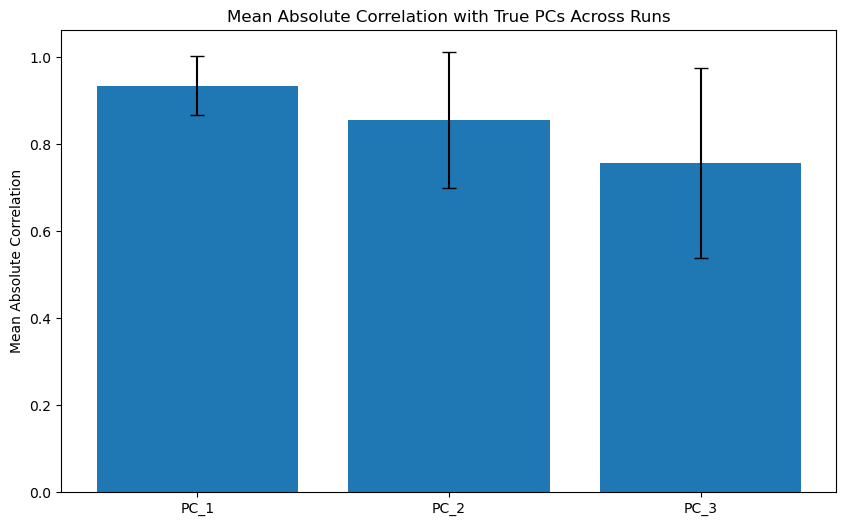

,PC_1,PC_2,PC_3
run_1,0.976415,0.940434,0.536941
run_2,0.995771,0.989333,0.970800
run_3,0.870544,0.725589,0.974798
run_4,0.909721,0.645530,0.751837
run_5,0.981013,0.903068,0.824315
run_6,0.988420,0.985876,0.929767
run_7,0.994648,0.980128,0.875192
run_8,0.967627,0.505527,0.931596
run_9,0.845581,0.999567,0.513156
run_10,0.870120,0.545836,0.845858


In [6]:
# 3.1 Complete mode
model = LeenCompletePCA(d, m, eta_w=2e-3, eta_q=5e-2, C=3.0,
                       ema_alpha=0.05, symmetrize_q=True, seed=None, settling_steps=100, noise_level=0.01)

# training_testing(model, X, number_of_samples, m)
model_paras = {
    'input_dim': d,
    'output_dim': m,
    'eta_w': 2e-4,
    'eta_q': 5e-3,
    'C': 3.0,
    'ema_alpha': 0.05,
    'symmetrize_q': True,
    'seed': None,
    'settling_steps': 10,
    'noise_level': 0.01
}

averaged_training_testing(LeenCompletePCA, model_paras=model_paras, X=X, runs=20, batch_size=100, graph=True)

run  1 | order = [0 2 1] | best|corr|=[1.    0.917 0.909]
run  2 | order = [1 2 0] | best|corr|=[0.986 0.509 1.   ]
run  3 | order = [1 0 2] | best|corr|=[0.986 1.    0.313]
run  4 | order = [0 1 2] | best|corr|=[1.    0.981 0.165]
run  5 | order = [0 2 1] | best|corr|=[1.    0.646 0.989]
run  6 | order = [2 1 0] | best|corr|=[0.967 0.994 1.   ]
run  7 | order = [2 0 1] | best|corr|=[0.915 1.    0.991]
run  8 | order = [1 2 0] | best|corr|=[0.987 0.829 1.   ]
run  9 | order = [0 1 2] | best|corr|=[1.    0.923 0.929]
run 10 | order = [1 0 2] | best|corr|=[0.789 1.    0.912]
run 11 | order = [1 2 0] | best|corr|=[0.999 0.999 1.   ]
run 12 | order = [0 1 2] | best|corr|=[1.    0.983 0.228]
run 13 | order = [0 1 2] | best|corr|=[1.    0.993 0.978]
run 14 | order = [0 1 2] | best|corr|=[1. 1. 1.]
run 15 | order = [1 0 2] | best|corr|=[0.958 1.    0.685]
run 16 | order = [1 0 2] | best|corr|=[1. 1. 1.]
run 17 | order = [2 1 0] | best|corr|=[0.405 0.986 1.   ]
run 18 | order = [0 2 1] | best|

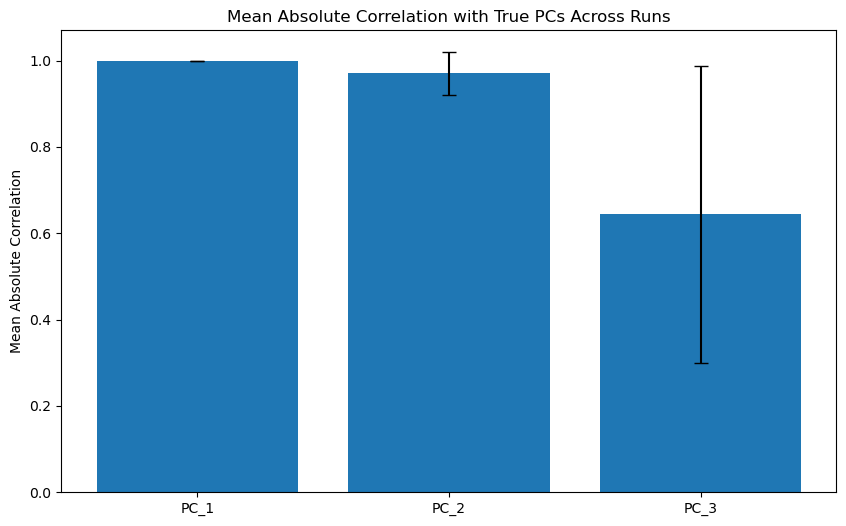

,PC_1,PC_2,PC_3
run_1,0.999999,0.908836,0.916868
run_2,0.999964,0.986315,0.508568
run_3,0.999997,0.986314,0.313386
run_4,1.000000,0.981499,0.164667
run_5,0.999956,0.988533,0.646257
run_6,0.999997,0.993634,0.967186
run_7,0.999962,0.991027,0.915219
run_8,0.999941,0.987301,0.829019
run_9,0.999999,0.922821,0.929295
run_10,0.999999,0.788596,0.912329


In [7]:
### 3.3 Minimal mode
model = LeenMinimalPCA(d, m, eta_w=2e-3, eta_q=1.5e-1, C=1.8,
                        ema_alpha=0.1,
                        seed=None)
# training_testing(model, X, number_of_samples, m)
model_paras = {
    'input_dim': d,
    'output_dim': m,
    'eta_w': 2e-3,
    'eta_q': 1.5e-1,
    'C': 1.8,
    'ema_alpha': 0.1,
    'symmetrize_q': True,
    'seed': None
}
averaged_training_testing(LeenMinimalPCA, model_paras=model_paras, X=X, runs=20, batch_size=100, graph=True)